In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('retail_store_inventory.csv')

In [3]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring


# EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [5]:
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [6]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring


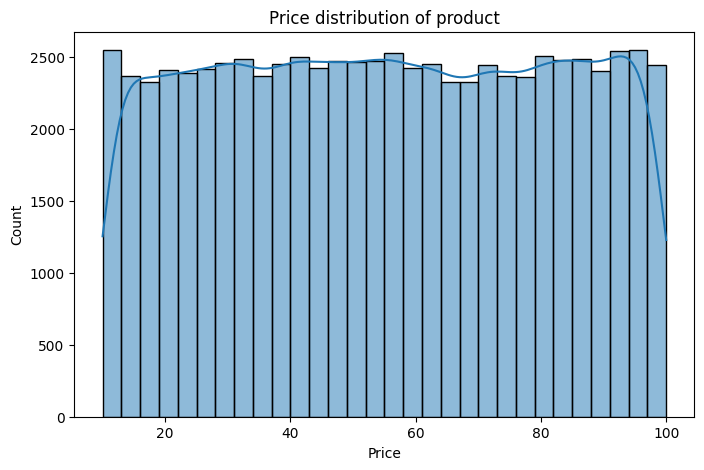

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Price distribution of product')
plt.show()

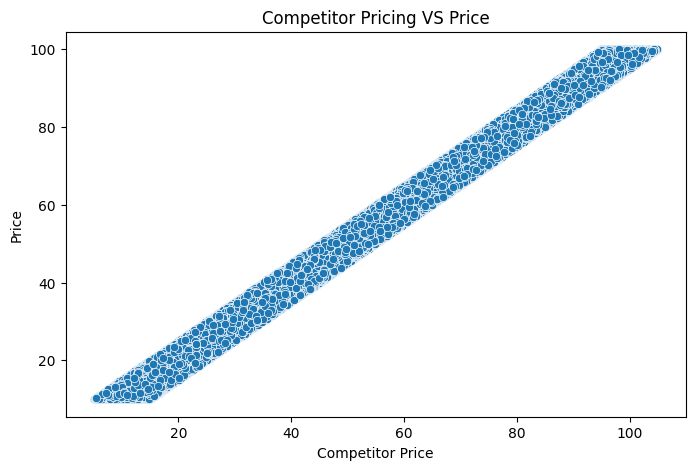

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Competitor Pricing'], y=df['Price'])
plt.title('Competitor Pricing VS Price')
plt.xlabel("Competitor Price")
plt.ylabel("Price")
plt.show()

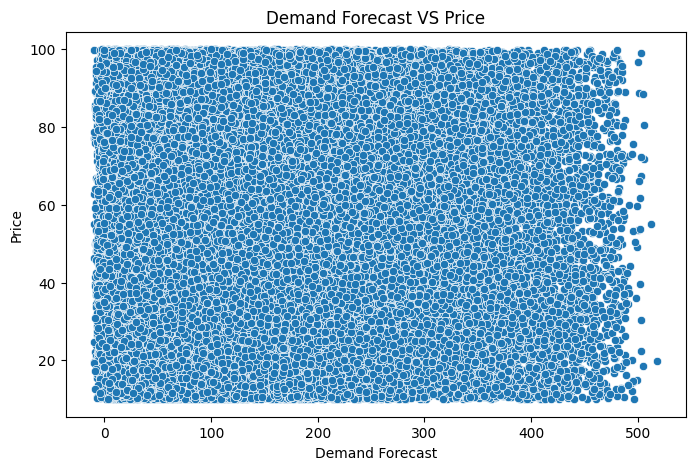

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Demand Forecast"], y=df['Price'])
plt.title('Demand Forecast VS Price')
plt.show()

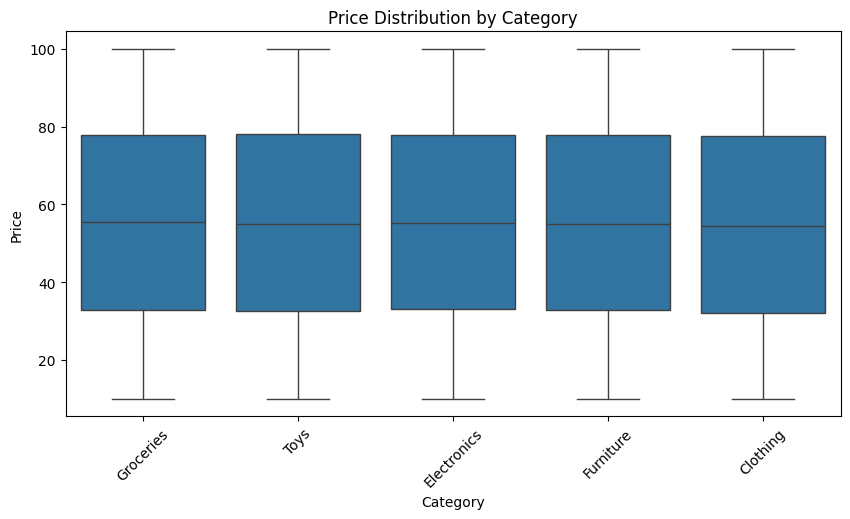

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["Category"], y=df["Price"])
plt.xticks(rotation=45)
plt.title("Price Distribution by Category")
plt.show()

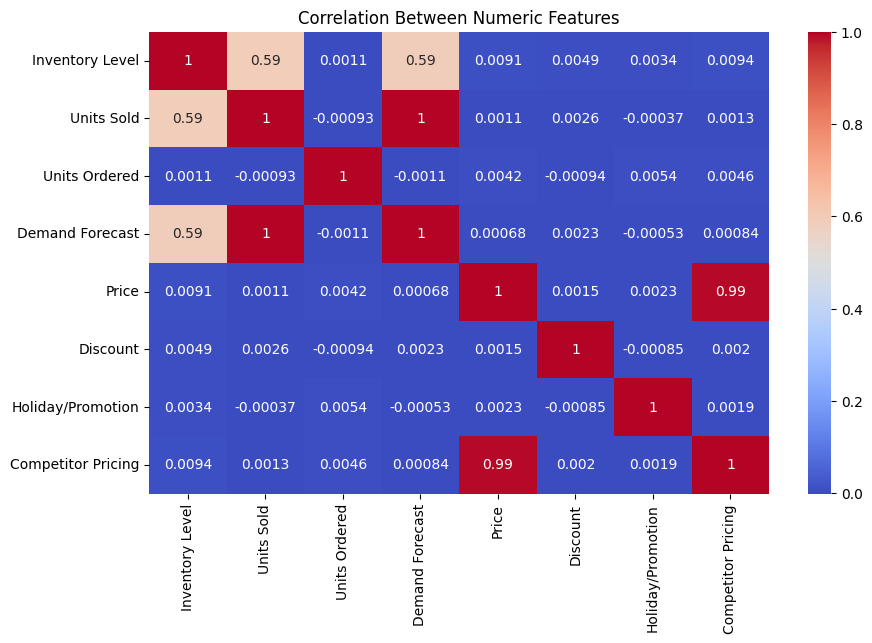

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.show()

# Removing Uneccessory Columns

In [14]:
df = df.drop(["Store ID","Product ID"], axis=1)

In [15]:
df["Date"] = pd.to_datetime(df["Date"])

df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["dayofweek"] = df["Date"].dt.dayofweek

In [16]:
df = df.drop("Date", axis=1)

# Stating Feature Engineering

In [17]:
df["price_diff"] = df["Price"] - df["Competitor Pricing"]

In [18]:
df["demand_inventory_ratio"] = df["Demand Forecast"] / (df["Inventory Level"] + 1)

In [19]:
df

,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,month,day,dayofweek,price_diff,demand_inventory_ratio
0,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,1,1,5,3.81,0.583922
1,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,1,1,5,-3.15,0.702634
2,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,1,1,5,-3.33,0.718641
3,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,1,1,5,-2.02,0.132298
4,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,1,1,5,4.69,0.055449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter,1,1,0,1.28,0.190309
73096,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn,1,1,0,-1.21,0.154236
73097,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter,1,1,0,0.20,0.142115
73098,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring,1,1,0,-2.66,0.721387


In [20]:
df["discount_effect"] = df["Discount"] * df["Units Sold"]

In [21]:
df

,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,month,day,dayofweek,price_diff,demand_inventory_ratio,discount_effect
0,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,1,1,5,3.81,0.583922,2540
1,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,1,1,5,-3.15,0.702634,3000
2,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,1,1,5,-3.33,0.718641,650
3,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,1,1,5,-2.02,0.132298,610
4,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,1,1,5,4.69,0.055449,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter,1,1,0,1.28,0.190309,160
73096,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn,1,1,0,-1.21,0.154236,510
73097,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter,1,1,0,0.20,0.142115,360
73098,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring,1,1,0,-2.66,0.721387,5280


# Target and Features

In [22]:
selected_features = [
    "Competitor Pricing",
    "Demand Forecast",
    "Inventory Level",
    "Discount",
    "Seasonality",
    "Holiday/Promotion",
    "Units Ordered"
]

X = df[selected_features]
Y = df["Price"]

# Categorical Cols

In [23]:
df.select_dtypes(include=['category', 'object']).columns.tolist()

['Category', 'Region', 'Weather Condition', 'Seasonality']

In [24]:
cat_columns = df.select_dtypes(include=['category', 'object']).columns.tolist()

In [25]:
cat_columns

['Category', 'Region', 'Weather Condition', 'Seasonality']

# Numerical Cols

In [26]:
num_cols = X.select_dtypes(exclude=['category', 'object']).columns.tolist()

# Train Test split

In [27]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [28]:
num_cols = ["Competitor Pricing", "Demand Forecast", "Inventory Level", "Discount", "Units Ordered"]
cat_cols = ["Seasonality", "Holiday/Promotion"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [29]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

# First model

In [30]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor()
}

In [31]:
results = []

for name, model in models.items():
    
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, Y_train)
    
    preds = pipe.predict(X_test)
    
    r2 = r2_score(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    rmse = np.sqrt(mean_squared_error(Y_test, preds))
    
    results.append([name, r2, mae, rmse])

In [32]:
model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

# Now Fits Model

In [33]:
pipe.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

# model Predicton Process

In [34]:
y_pred = pipe.predict(X_test)

In [35]:
y_pred

array([42.37552 , 16.025438, 18.007002, ..., 23.704845, 63.88895 ,
       58.555534], shape=(21930,), dtype=float32)

# now check model predciation test

In [36]:
print("R2 Score:", r2_score(Y_test, y_pred))
print("MAE:", mean_absolute_error(Y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred)))

R2 Score: 0.9877593682126042
MAE: 2.4626063893583883
RMSE: 2.8819994591140365


In [37]:
results_df = pd.DataFrame(results, columns=["Model","R2","MAE","RMSE"])
results_df

,Model,R2,MAE,RMSE
0,Linear Regression,0.987667,2.508390,2.892878
1,Ridge,0.987667,2.508377,2.892883
2,Lasso,0.986118,2.585277,3.069094
3,Random Forest,0.987425,2.484391,2.921057
4,XGBoost,0.987759,2.462606,2.881999


In [38]:
final_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

In [39]:
final_model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [40]:
preds = final_model.predict(X_test)

In [41]:
preds

array([42.13375583, 17.13069316, 18.45760441, ..., 23.18973119,
       63.45933465, 58.54299313], shape=(21930,))

In [42]:
print("R2:", r2_score(Y_test, preds))
print("MAE:", mean_absolute_error(Y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, preds)))

R2: 0.987666782455551
MAE: 2.5083895565791945
RMSE: 2.892878367944021


In [43]:
feature_names = final_model.named_steps["preprocessing"].get_feature_names_out()

In [44]:
coefficients = final_model.named_steps["model"].coef_

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance = importance.sort_values(by="Coefficient", ascending=False)

In [45]:
importance.head(7)

,Feature,Coefficient
0,num__Competitor Pricing,25.849775
10,cat__Holiday/Promotion_1,0.014638
2,num__Inventory Level,0.005835
7,cat__Seasonality_Summer,0.004236
6,cat__Seasonality_Spring,0.002814
1,num__Demand Forecast,0.002706
5,cat__Seasonality_Autumn,-0.001839


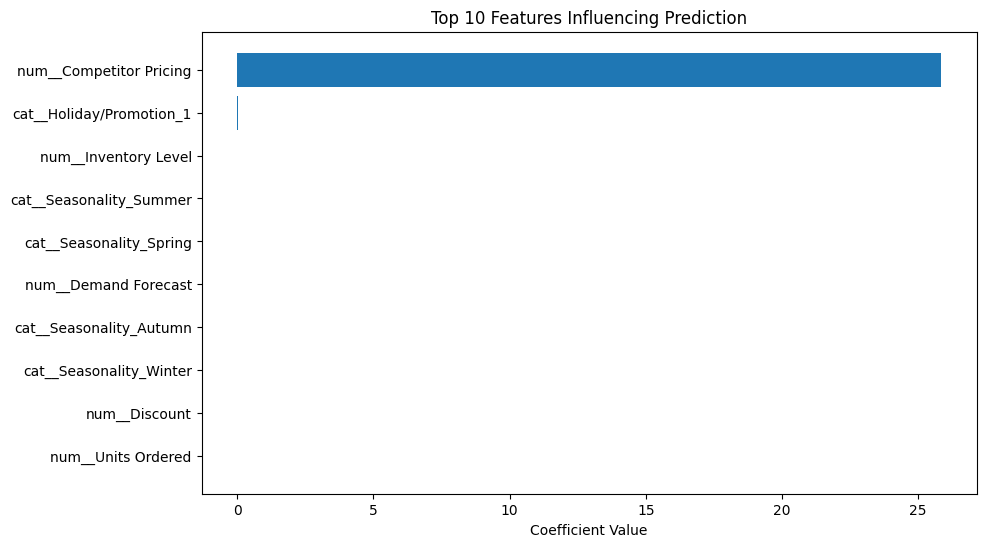

In [46]:
top_features= importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Top 10 Features Influencing Prediction")
plt.gca().invert_yaxis()

plt.show()

In [47]:
X.sample()

,Competitor Pricing,Demand Forecast,Inventory Level,Discount,Seasonality,Holiday/Promotion,Units Ordered
842,69.07,112.01,159,10,Summer,1,47


In [48]:
sample = pd.DataFrame({
    "Inventory Level": [101],
    "Units Ordered": [86],
    "Demand Forecast": [258.59],
    "Discount": [20],
    "Holiday/Promotion": [1],
    "Seasonality": ['Autumn'],
    "Competitor Pricing": [76.25],
})

In [49]:
prediction = final_model.predict(sample)

print("Predicted Price:", prediction[0])

Predicted Price: 75.96333892021377


In [50]:
df.iloc[56468]

Category                  Clothing
Region                        West
Inventory Level                272
Units Sold                     265
Units Ordered                   86
Demand Forecast             258.59
Price                        76.01
Discount                        20
Weather Condition           Cloudy
Holiday/Promotion                1
Competitor Pricing           76.25
Seasonality                 Autumn
month                            7
day                             19
dayofweek                        2
price_diff                   -0.24
demand_inventory_ratio    0.947216
discount_effect               5300
Name: 56468, dtype: object

In [51]:
comparison = pd.DataFrame({
    "Actual": Y_test,
    "Predicted": preds
})

comparison.head(10)

,Actual,Predicted
66127,40.47,42.133756
43485,18.65,17.130693
34304,20.33,18.457604
34317,98.65,94.869155
38631,10.04,13.483676
42111,11.27,7.188637
63601,30.53,34.861160
30662,50.23,54.139102
21439,61.78,59.592459
12107,17.63,21.654385


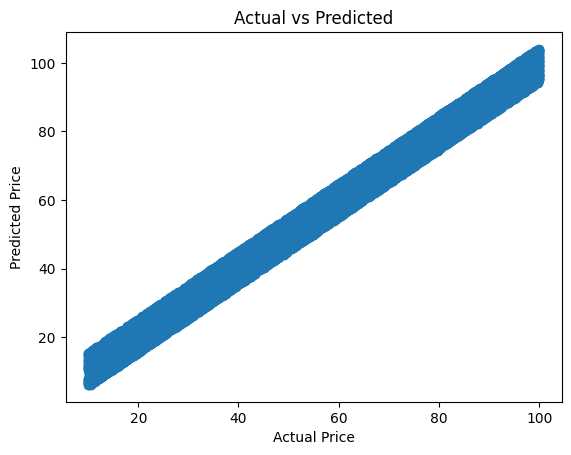

In [52]:
plt.scatter(Y_test, preds)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [53]:
import joblib

joblib.dump(final_model, "pricing_model.pkl")

['pricing_model.pkl']